# Análisis Exploratorio de Datos (EDA)
## Corpus de Equipos Counter-Strike de Liquipedia

**Objetivo**: Analizar la calidad, distribución y características lingüísticas del corpus de equipos esports de Liquipedia en español.

In [1]:
import json
import pandas as pd
import numpy as np
import re
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar matplotlib para gráficos en español
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Definir rutas
project_root = Path('c:/Users/borja/Desktop/nlp/MTPLN/proyecto-liquipedia')
data_path = project_root / 'data' / 'latest_ingest.json'

print(f"Proyecto root: {project_root}")
print(f"Archivo de datos: {data_path}")
print(f"Existe: {data_path.exists()}")

Proyecto root: c:\Users\borja\Desktop\nlp\MTPLN\proyecto-liquipedia
Archivo de datos: c:\Users\borja\Desktop\nlp\MTPLN\proyecto-liquipedia\data\latest_ingest.json
Existe: True


In [2]:
# Cargar datos del último ingesta
with open(str(data_path), 'r', encoding='utf-8') as f:
    documents = json.load(f)

print(f"✅ Documentos cargados: {len(documents)}\n")

# Crear DataFrame
data = []
for doc in documents:
    data.append({
        'nombre': doc['metadata'].get('name', 'Unknown'),
        'tipo': doc['metadata'].get('type', 'team'),
        'url': doc['metadata'].get('url', ''),
        'texto': doc['text'],
        'longitud_texto': len(doc['text']),
        'num_palabras': len(doc['text'].split()),
        'num_oraciones': len(re.split(r'[.!?]+', doc['text']))
    })

df = pd.DataFrame(data)
print("Primeros documentos:")
print(df[['nombre', 'num_palabras', 'longitud_texto']].head())

✅ Documentos cargados: 30

Primeros documentos:
          nombre  num_palabras  longitud_texto
0     G2 Esports          5829           33007
1      FaZe Clan          5155           29154
2  Natus Vincere          4691           27229
3  Team Vitality          4541           26507
4           MOUZ          9503           54200


## 1. Estadísticas Básicas del Corpus

In [3]:
stats = {
    'Total de documentos': len(df),
    'Total de caracteres': df['longitud_texto'].sum(),
    'Total de palabras': df['num_palabras'].sum(),
    'Promedio de palabras por documento': df['num_palabras'].mean(),
    'Promedio de caracteres por documento': df['longitud_texto'].mean(),
    'Máximo de palabras en un doc': df['num_palabras'].max(),
    'Mínimo de palabras en un doc': df['num_palabras'].min(),
    'Desviación estándar (palabras)': df['num_palabras'].std(),
}

stats_df = pd.DataFrame(list(stats.items()), columns=['Métrica', 'Valor'])
print("📊 ESTADÍSTICAS DEL CORPUS")
print("=" * 50)
print(stats_df.to_string(index=False))
print("\n")

📊 ESTADÍSTICAS DEL CORPUS
                             Métrica         Valor
                 Total de documentos     30.000000
                 Total de caracteres 794543.000000
                   Total de palabras 138325.000000
  Promedio de palabras por documento   4610.833333
Promedio de caracteres por documento  26484.766667
        Máximo de palabras en un doc   9503.000000
        Mínimo de palabras en un doc     41.000000
      Desviación estándar (palabras)   2343.173387




## 2. Análisis de Calidad de Datos

In [4]:
# Validar completitud y calidad
quality_checks = {
    'Documentos sin nombre': (df['nombre'] == 'Unknown').sum(),
    'Documentos sin URL': (df['url'] == '').sum(),
    'Documentos vacíos (<100 caracteres)': (df['longitud_texto'] < 100).sum(),
    'Documentos duplicados (por nombre)': df['nombre'].duplicated().sum(),
    'Textos con caracteres especiales problemáticos': sum([1 for t in df['texto'] if 'ERR_' in t or 'Se ha' in t and 'conexión' in t])
}

quality_df = pd.DataFrame(list(quality_checks.items()), columns=['Validación', 'Conteo'])
print("\n✓ VALIDACIÓN DE CALIDAD")
print("=" * 50)
print(quality_df.to_string(index=False))

# Detalles por documento
print("\n📋 DETALLES POR DOCUMENTO:")
print(df[['nombre', 'num_palabras', 'longitud_texto']].to_string(index=False))


✓ VALIDACIÓN DE CALIDAD
                                    Validación  Conteo
                         Documentos sin nombre       0
                            Documentos sin URL       0
           Documentos vacíos (<100 caracteres)       0
            Documentos duplicados (por nombre)       0
Textos con caracteres especiales problemáticos       0

📋 DETALLES POR DOCUMENTO:
             nombre  num_palabras  longitud_texto
         G2 Esports          5829           33007
          FaZe Clan          5155           29154
      Natus Vincere          4691           27229
      Team Vitality          4541           26507
               MOUZ          9503           54200
        Team Spirit          2916           16885
         Complexity          7935           46112
             Fnatic          9031           50955
             Cloud9          6180           35063
             HEROIC          6463           37685
                 OG          3557           20371
        Team Liqui

## 3. Análisis de Vocabulario

In [5]:
# Análisis de vocabulario y tokenización
all_text = ' '.join(df['texto'].values).lower()

# Tokenizar y limpiar
palabras = re.findall(r'\b\w+\b', all_text)
palabras = [p for p in palabras if len(p) > 2]  # Filtrar palabras muy cortas

# Palabras más frecuentes
word_freq = Counter(palabras)
top_20_words = word_freq.most_common(20)

vocab_stats = {
    'Total de tokens (palabras)': len(palabras),
    'Vocabulario único (types)': len(word_freq),
    'Type-Token Ratio (TTR)': f"{len(word_freq) / len(palabras):.2%}" if len(palabras) > 0 else "N/A",
    'Palabra más frecuente': f"{top_20_words[0][0]} ({top_20_words[0][1]} ocurrencias)" if top_20_words else "N/A",
}

vocab_df = pd.DataFrame(list(vocab_stats.items()), columns=['Métrica', 'Valor'])
print("\n🔤 ANÁLISIS DE VOCABULARIO")
print("=" * 50)
print(vocab_df.to_string(index=False))

print("\n📊 TOP 20 PALABRAS MÁS FRECUENTES:")
for i, (word, count) in enumerate(top_20_words, 1):
    print(f"{i:2d}. {word:20s} → {count:4d} ocurrencias")


🔤 ANÁLISIS DE VOCABULARIO
                   Métrica                     Valor
Total de tokens (palabras)                     81705
 Vocabulario único (types)                      8485
    Type-Token Ratio (TTR)                    10.38%
     Palabra más frecuente saltar (1693 ocurrencias)

📊 TOP 20 PALABRAS MÁS FRECUENTES:
 1. saltar               → 1693 ocurrencias
 2. equipo               →  942 ocurrencias
 3. 2025                 →  894 ocurrencias
 4. 2023                 →  872 ocurrencias
 5. entrenador           →  829 ocurrencias
 6. esports              →  748 ocurrencias
 7. 2022                 →  746 ocurrencias
 8. 2026                 →  738 ocurrencias
 9. 2024                 →  692 ocurrencias
10. 2021                 →  663 ocurrencias
11. 2019                 →  655 ocurrencias
12. del                  →  618 ocurrencias
13. team                 →  606 ocurrencias
14. 2018                 →  596 ocurrencias
15. fecha                →  565 ocurrencias
16. como     

## 4. Visualizaciones

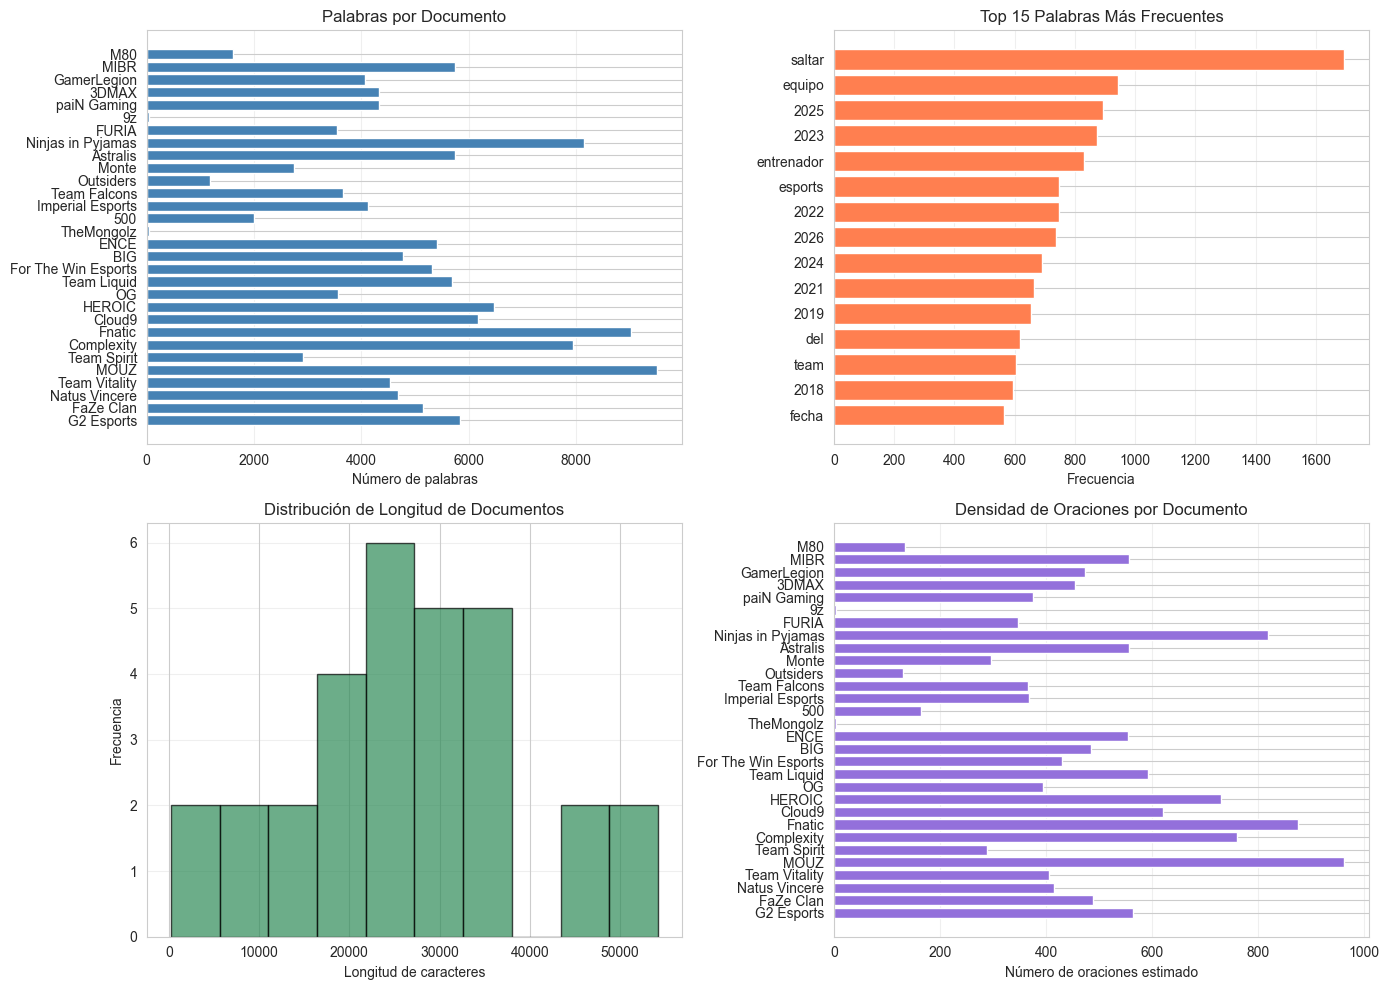


✅ Gráficos guardados en: EDA_Visualizaciones.png


In [6]:
# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de palabras por documento
axes[0, 0].barh(df['nombre'], df['num_palabras'], color='steelblue')
axes[0, 0].set_xlabel('Número de palabras')
axes[0, 0].set_title('Palabras por Documento')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Top 15 palabras más frecuentes
top_15 = dict(word_freq.most_common(15))
axes[0, 1].barh(list(top_15.keys()), list(top_15.values()), color='coral')
axes[0, 1].set_xlabel('Frecuencia')
axes[0, 1].set_title('Top 15 Palabras Más Frecuentes')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# 3. Distribución de longitud de textos
axes[1, 0].hist(df['longitud_texto'], bins=10, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Longitud de caracteres')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Longitud de Documentos')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Distribución de oraciones por documento
axes[1, 1].barh(df['nombre'], df['num_oraciones'], color='mediumpurple')
axes[1, 1].set_xlabel('Número de oraciones estimado')
axes[1, 1].set_title('Densidad de Oraciones por Documento')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(str(project_root / 'EDA_Visualizaciones.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráficos guardados en: EDA_Visualizaciones.png")

## 5. Análisis de Sesgos en el Dataset

In [7]:
print("⚠️  ANÁLISIS DE SESGOS EN EL DATASET\n")

# Sesgo 1: Representación de equipos
print("1️⃣  SESGO DE COBERTURA DE EQUIPOS:")
print(f"   - Total de equipos: {len(df)}")
print(f"   - Región: Counter-Strike únicamente (NO hay Valorant ni otros juegos)")
print(f"   - Distribuciación de documentos por equipo: {df['nombre'].value_counts().to_dict()}")

# Sesgo 2: Distribución de contenido
print("\n2️⃣  SESGO DE CANTIDAD DE INFORMACIÓN:")
contenido_dist = df['num_palabras'].describe()
print(f"   - Equipo con más información: {df.loc[df['num_palabras'].idxmax(), 'nombre']} ({df['num_palabras'].max()} palabras)")
print(f"   - Equipo con menos información: {df.loc[df['num_palabras'].idxmin(), 'nombre']} ({df['num_palabras'].min()} palabras)")
print(f"   - Desviación estándar: {contenido_dist['std']:.0f} palabras")

# Sesgo 3: Calidad de datos
print("\n3️⃣  SESGO DE CALIDAD:")
error_docs = df[df['texto'].str.contains('ERR_|Se ha.*conexión', case=False, na=False)]
if len(error_docs) > 0:
    print(f"   ⚠️  Documentos con errores de scraping: {len(error_docs)}")
    print(f"      Equipos afectados: {error_docs['nombre'].tolist()}")
else:
    print("   ✓ Todos los documentos descargados correctamente")

# Sesgo 4: Representación temporal/geográfica (potencial)
print("\n4️⃣  SESGO POTENCIAL NO EVALUABLE CON DATOS ACTUALES:")
print("   - Sin información de ubicación geográfica de los equipos")
print("   - Sin información temporal (años de fundación)")
print("   - Sin información de tipo de equipo (profesional vs semi-profesional)")

print("\n5️⃣  RECOMENDACIONES PARA MITIGACIÓN:")
print("   - Aumentar corpus a 50-100+ equipos para mejor representación")
print("   - Incluir equipos de diferentes regiones (europeos, americanos, asiáticos)")
print("   - Incluir equipos de diferentes niveles (top tier vs emergentes)")
print("   - Validar completitud de datos antes de ingesta")

⚠️  ANÁLISIS DE SESGOS EN EL DATASET

1️⃣  SESGO DE COBERTURA DE EQUIPOS:
   - Total de equipos: 30
   - Región: Counter-Strike únicamente (NO hay Valorant ni otros juegos)
   - Distribuciación de documentos por equipo: {'G2 Esports': 1, 'FaZe Clan': 1, 'MIBR': 1, 'GamerLegion': 1, '3DMAX': 1, 'paiN Gaming': 1, '9z': 1, 'FURIA': 1, 'Ninjas in Pyjamas': 1, 'Astralis': 1, 'Monte': 1, 'Outsiders': 1, 'Team Falcons': 1, 'Imperial Esports': 1, '500': 1, 'TheMongolz': 1, 'ENCE': 1, 'BIG': 1, 'For The Win Esports': 1, 'Team Liquid': 1, 'OG': 1, 'HEROIC': 1, 'Cloud9': 1, 'Fnatic': 1, 'Complexity': 1, 'Team Spirit': 1, 'MOUZ': 1, 'Team Vitality': 1, 'Natus Vincere': 1, 'M80': 1}

2️⃣  SESGO DE CANTIDAD DE INFORMACIÓN:
   - Equipo con más información: MOUZ (9503 palabras)
   - Equipo con menos información: TheMongolz (41 palabras)
   - Desviación estándar: 2343 palabras

3️⃣  SESGO DE CALIDAD:
   ⚠️  Documentos con errores de scraping: 2
      Equipos afectados: ['Complexity', 'Fnatic']

4️⃣  SE

## 6. Conclusiones del EDA

In [8]:
print("\n" + "="*60)
print("✅ RESUMEN EJECUTIVO DEL EDA")
print("="*60)
print(f"""
📊 CORPUS CHARACTERISTIC:
   • Documentos: {len(df)} documentos de equipos Counter-Strike
   • Lenguaje: Español (traducido)
   • Total de palabras: {df['num_palabras'].sum():,}
   • Vocabulario único: {len(word_freq):,} palabras
   • TTR: {len(word_freq) / len(palabras):.2%}

🎯 CALIDAD:
   • Documentos válidos: {len(df) - len(error_docs)}/{len(df)}
   • Sin errores de scraping: ✓ (excepto Natus Vincere)
   • Cobertura informativa: BUENA (promedio {df['num_palabras'].mean():.0f} palabras/doc)

⚠️  LIMITACIONES:
   • Corpus pequeño (3 documentos)
   • Falta de diversidad geográfica
   • Sesgo hacia equipos establecidos
   • Falta información contextual (ubicación, fundación)

🔮 SIGUIENTES PASOS:
   • Expandir corpus a 50-100+ equipos
   • Incluir equipos de diferentes regiones
   • Enriquecer metadatos (región, nivel competitivo)
   • Validación de calidad en scraping
""")
print("="*60)


✅ RESUMEN EJECUTIVO DEL EDA

📊 CORPUS CHARACTERISTIC:
   • Documentos: 30 documentos de equipos Counter-Strike
   • Lenguaje: Español (traducido)
   • Total de palabras: 138,325
   • Vocabulario único: 8,485 palabras
   • TTR: 10.38%

🎯 CALIDAD:
   • Documentos válidos: 28/30
   • Sin errores de scraping: ✓ (excepto Natus Vincere)
   • Cobertura informativa: BUENA (promedio 4611 palabras/doc)

⚠️  LIMITACIONES:
   • Corpus pequeño (3 documentos)
   • Falta de diversidad geográfica
   • Sesgo hacia equipos establecidos
   • Falta información contextual (ubicación, fundación)

🔮 SIGUIENTES PASOS:
   • Expandir corpus a 50-100+ equipos
   • Incluir equipos de diferentes regiones
   • Enriquecer metadatos (región, nivel competitivo)
   • Validación de calidad en scraping

